**Goal:** turn one weather station's 65-year daily record -- 23,742 rows --
into its three temporal patterns: the long-term trend, the seasonal cycle,
and the noise (with a hurricane hiding in it). Pairs with the concept note
[Patterns in Time: Trend, Seasonality, and Noise](l13_concept_temporal_patterns.qmd).

> This page is the read-only view. To run the lab, open the notebook
> (`l13_lab_san_juan_climate.ipynb`) -- in Colab via the badge on the
> concept page, or locally.

## Prerequisites & Setup

Run this first. One public-domain dataset, bundled with the course and with
a live download fallback:

- **Weather record:** NOAA NCEI Global Historical Climatology Network -
  Daily, station `RQW00011641` (San Juan Luis Munoz Marin International
  Airport). Daily maximum temperature (TMAX, C), minimum temperature
  (TMIN, C), and precipitation (PRCP, mm), 1960-01-01 to 2024-12-31.
  US-government work, public domain. Note the fallback URL: it is a plain
  web API with query parameters, exactly the L04 pattern.

There is no randomness in this lab -- every number is fully deterministic,
so no seed is needed.

In [1]:
# Setup: run this cell first (required for Colab -- it resets on open)
%pip install -q pandas matplotlib

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NOAA NCEI GHCN-Daily, San Juan L. M. Marin Intl Airport (public domain)
WEATHER_LOCAL = "data/sju_weather_1960_2024.csv"
WEATHER_URL = ("https://www.ncei.noaa.gov/access/services/data/v1"
               "?dataset=daily-summaries&stations=RQW00011641"
               "&startDate=1960-01-01&endDate=2024-12-31"
               "&dataTypes=TMAX,TMIN,PRCP&format=csv&units=metric")

if not os.path.exists(WEATHER_LOCAL):
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(WEATHER_URL, WEATHER_LOCAL)

weather = pd.read_csv(WEATHER_LOCAL, parse_dates=["DATE"]).set_index("DATE").sort_index()
print("Rows:", len(weather))
print("Range:", weather.index.min().date(), "to", weather.index.max().date())
print()
print(weather.head(3))

Note: you may need to restart the kernel to use updated packages.


Rows: 23742
Range: 1960-01-01 to 2024-12-31

                STATION  PRCP  TMAX  TMIN
DATE                                     
1960-01-01  RQW00011641   0.0  28.9  20.0
1960-01-02  RQW00011641   0.0  29.4  20.6
1960-01-03  RQW00011641   0.0  28.9  20.6


<details><summary>Expected Output</summary>

~~~text
Rows: 23742
Range: 1960-01-01 to 2024-12-31

                STATION  PRCP  TMAX  TMIN
DATE                                     
1960-01-01  RQW00011641   0.0  28.9  20.0
1960-01-02  RQW00011641   0.0  29.4  20.6
1960-01-03  RQW00011641   0.0  28.9  20.6
~~~
</details>

> **Read it:** `parse_dates=` plus `set_index("DATE")` is the move that
> makes this a *time series* and not just a table: the timestamps become
> the row labels, which is what unlocks everything below (date slicing,
> resampling, rolling windows). One row per day since January 1960.

## Step 1: One Thermometer, 23,742 Rows (Worked)

First, a single working variable: the **daily mean temperature**, midway
between the day's high and low. Deriving it is a handcrafted feature --
exactly L10's move, one line.

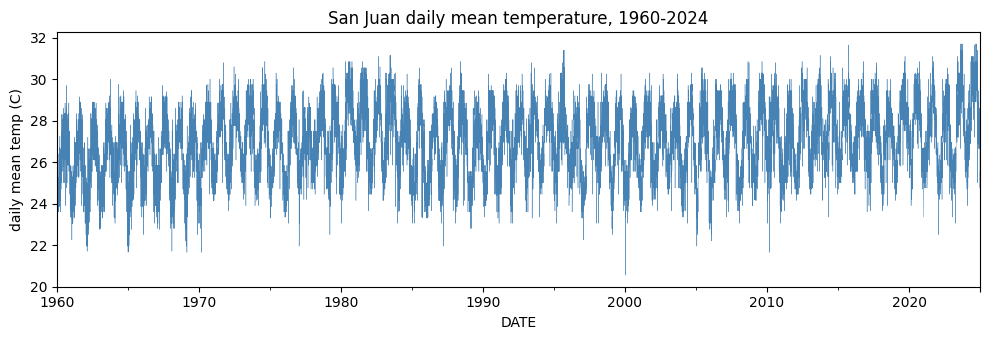

In [2]:
weather["TMID"] = (weather["TMAX"] + weather["TMIN"]) / 2   # daily mean temperature

fig, ax = plt.subplots(figsize=(10, 3.5))
weather["TMID"].plot(ax=ax, linewidth=0.3, color="steelblue")
ax.set_ylabel("daily mean temp (C)")
ax.set_title("San Juan daily mean temperature, 1960-2024")
plt.tight_layout()
plt.show()

> **Read it:** 23,742 points form a solid ribbon. You can just make out
> that the ribbon wobbles (some yearly rhythm?) and maybe drifts upward,
> but nothing is quotable from this picture. That is the lesson in one
> figure: at the wrong scale, the patterns are *in* the data but not
> *visible*. The rest of the lab extracts them one by one.

Because the row labels are timestamps, slicing by date is effortless --
`.loc["2017-09-15":"2017-09-25"]` reads as dates, no boolean masks needed.
Point it at the worst week in the station's recent memory:

In [3]:
sept17 = weather.loc["2017-09-15":"2017-09-25", ["PRCP", "TMAX", "TMIN"]]
print(sept17)

             PRCP  TMAX  TMIN
DATE                         
2017-09-15    0.0  32.8  26.7
2017-09-16    0.0  32.8  26.1
2017-09-17   18.0  32.2  26.7
2017-09-18    0.8  31.7  26.7
2017-09-19    5.3  31.7  26.7
2017-09-20  180.6   NaN   NaN
2017-09-21    9.7   NaN   NaN
2017-09-22   86.1  32.2  27.8
2017-09-23    0.0  28.9  27.8
2017-09-24    0.0  34.4  27.2
2017-09-25    0.0  32.8  27.2


<details><summary>Expected Output</summary>

~~~text
             PRCP  TMAX  TMIN
DATE                         
2017-09-15    0.0  32.8  26.7
2017-09-16    0.0  32.8  26.1
2017-09-17   18.0  32.2  26.7
2017-09-18    0.8  31.7  26.7
2017-09-19    5.3  31.7  26.7
2017-09-20  180.6   NaN   NaN
2017-09-21    9.7   NaN   NaN
2017-09-22   86.1  32.2  27.8
2017-09-23    0.0  28.9  27.8
2017-09-24    0.0  34.4  27.2
2017-09-25    0.0  32.8  27.2
~~~
</details>

> **Read it:** September 20, 2017 -- Hurricane Maria. The rain gauge
> recorded 180.6 mm and then the thermometer went silent for two days:
> those `NaN`s are not sloppy data entry, they are the storm knocking out
> the instrument. The data gap *is* the event.

How bad is the gap problem overall? Find every incomplete day in 65 years:

In [4]:
gaps = weather[weather[["TMAX", "TMIN", "PRCP"]].isna().any(axis=1)]
print(gaps[["TMAX", "TMIN", "PRCP"]])
print()
for col in ["TMAX", "TMIN", "PRCP"]:
    weather[col] = weather[col].interpolate(method="time")
weather["TMID"] = (weather["TMAX"] + weather["TMIN"]) / 2
print("Missing values after interpolation:",
      int(weather[["TMAX", "TMIN", "PRCP"]].isna().sum().sum()))

            TMAX  TMIN   PRCP
DATE                         
1997-10-12  29.4  22.8    NaN
1997-10-13  31.1  23.9    NaN
1997-10-14  31.1  23.9    NaN
2017-09-20   NaN   NaN  180.6
2017-09-21   NaN   NaN    9.7

Missing values after interpolation: 0


<details><summary>Expected Output</summary>

~~~text
            TMAX  TMIN   PRCP
DATE                         
1997-10-12  29.4  22.8    NaN
1997-10-13  31.1  23.9    NaN
1997-10-14  31.1  23.9    NaN
2017-09-20   NaN   NaN  180.6
2017-09-21   NaN   NaN    9.7

Missing values after interpolation: 0
~~~
</details>

> **Read it:** five incomplete days out of 23,742 -- a remarkably clean
> record. L09 filled gaps with a column's *median*, but for a time series
> that is the wrong neighbor to ask: October 13, 1997 should look like
> October 12 and 14, not like the median of 65 years of days.
> `interpolate(method="time")` draws the straight line between the nearest
> real observations instead. (For the three missing rain days a zero fill
> would be just as defensible; with 5 days in 65 years, either choice is
> invisible at every scale this lab works at.)

## Step 2: The Scale Ladder (Worked + Completion)

The daily ribbon hides everything, so change the scale: **resampling**
regroups the rows into coarser time bins and aggregates each bin to one
number. The aggregation is a *decision*, not a default -- temperature is a
level, so a monthly value is the **mean**; rain accumulates, so a monthly
value is the **sum**. (Average the daily rain instead and a hurricane
month full of dry days looks unremarkable.)

In [5]:
temp_m = weather["TMID"].resample("ME").mean()    # monthly MEAN temperature
rain_m = weather["PRCP"].resample("ME").sum()     # monthly TOTAL rainfall
temp_y = weather["TMID"].resample("YE").mean()    # annual mean temperature
rain_y = weather["PRCP"].resample("YE").sum()     # annual total rainfall
print("Daily rows:  ", len(weather))
print("Monthly rows:", len(temp_m))
print("Annual rows: ", len(temp_y))

Daily rows:   23742
Monthly rows: 780
Annual rows:  65


<details><summary>Expected Output</summary>

~~~text
Daily rows:   23742
Monthly rows: 780
Annual rows:  65
~~~
</details>

Now look at the same thermometer at all three scales:

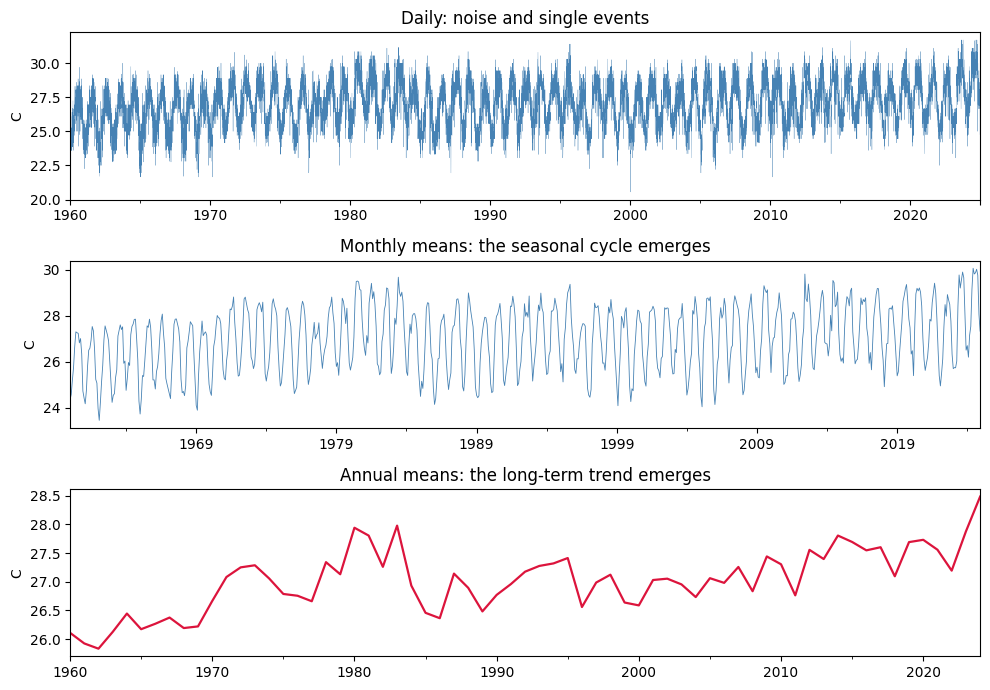

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7))
weather["TMID"].plot(ax=axes[0], linewidth=0.2, color="steelblue")
axes[0].set_title("Daily: noise and single events")
temp_m.plot(ax=axes[1], linewidth=0.6, color="steelblue")
axes[1].set_title("Monthly means: the seasonal cycle emerges")
temp_y.plot(ax=axes[2], linewidth=1.6, color="crimson")
axes[2].set_title("Annual means: the long-term trend emerges")
for ax in axes:
    ax.set_ylabel("C")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

> **Read it:** same data, three different stories. Daily shows the fuzz
> (and the occasional extreme day); monthly reveals a clean wave repeating
> every year -- the seasonal cycle; annual averages the wave away and what
> remains is a slow climb. **Each pattern is visible at exactly one scale
> and invisible at the others.** Choosing the scale is choosing the
> question; note also what coarsening *costs*: at the annual scale,
> Hurricane Maria does not exist.

Your turn -- the annual rain series says which years were extreme:

In [7]:
# Uncomment and fill the ____ : idxmax() gives the index label of the maximum --
# here the label is a timestamp (the year-end date), so .year extracts the year.
# wettest = rain_y.____()
# driest = rain_y.idxmin()
# print("Wettest year:", wettest.year, "-", round(rain_y.max()), "mm")
# print("Driest year: ", driest.year, "-", round(rain_y.min()), "mm")

<details><summary>Expected Output</summary>

~~~text
Wettest year: 2010 - 2275 mm
Driest year:  1991 - 903 mm
~~~
*(A two-and-a-half-fold swing between the extremes -- year-to-year rainfall
is far more volatile than year-to-year temperature.)*
</details>

## Step 3: Finding the Trend (Worked)

The monthly panel above still mixes the seasonal wave with any long-term
drift. A **rolling mean** separates them: replace each point by the average
of a window centered on it. Make the window exactly one cycle long --
12 months -- and the seasonal wave averages to the same value everywhere,
leaving only the drift.

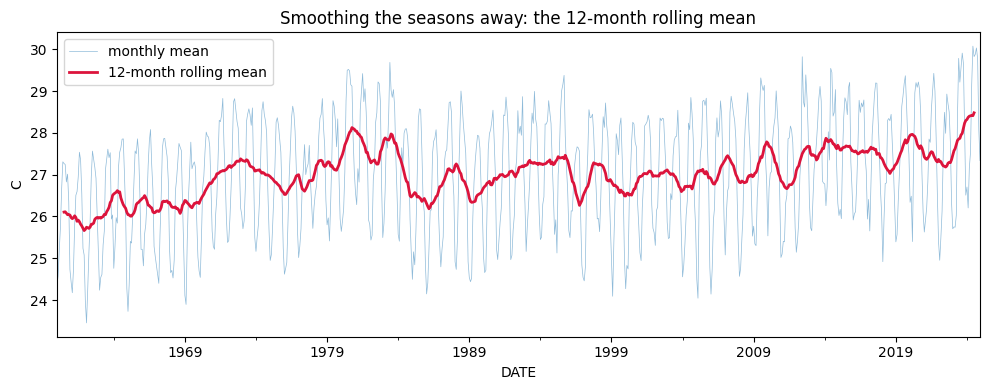

1960s annual mean:      26.17 C
2015-2024 annual mean:  27.65 C
Warmest year on record: 2024 (28.49 C)


In [8]:
roll12 = temp_m.rolling(window=12, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 4))
temp_m.plot(ax=ax, linewidth=0.5, alpha=0.5, label="monthly mean")
roll12.plot(ax=ax, linewidth=2, color="crimson", label="12-month rolling mean")
ax.set_ylabel("C")
ax.legend()
ax.set_title("Smoothing the seasons away: the 12-month rolling mean")
plt.tight_layout()
plt.show()

print(f"1960s annual mean:      {temp_y['1960':'1969'].mean():.2f} C")
print(f"2015-2024 annual mean:  {temp_y['2015':'2024'].mean():.2f} C")
print(f"Warmest year on record: {temp_y.idxmax().year} ({temp_y.max():.2f} C)")

<details><summary>Expected Output</summary>

~~~text
1960s annual mean:      26.17 C
2015-2024 annual mean:  27.65 C
Warmest year on record: 2024 (28.49 C)
~~~
</details>

> **Read it:** the red line wanders, but its destination is unambiguous:
> San Juan's mean temperature is about **1.5 C higher** than in the 1960s,
> and the warmest year in the station's record is the most recent complete
> one, 2024. Note what the rolling mean did *not* do: it found no trend
> that was not already in the data -- it only made it visible by removing
> the wave that was hiding it.

## Step 4: Finding the Seasons -- and the Period (Worked + Completion)

The wave repeats every year, so stack the years on top of each other:
group every January from 1960 to 2024 together, every February, and so on.
The 12 group means are called a **climatology** -- the "normal" year for
this station.

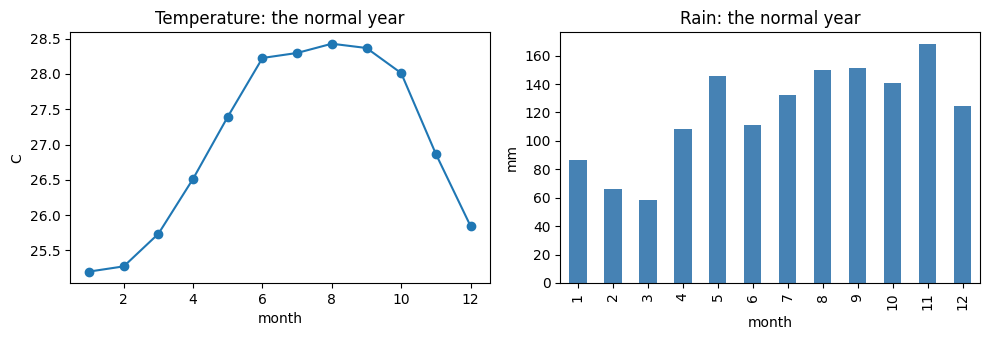

Seasonal amplitude: 3.2 C


In [9]:
temp_clim = temp_m.groupby(temp_m.index.month).mean()
rain_clim = rain_m.groupby(rain_m.index.month).mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
temp_clim.plot(ax=axes[0], marker="o")
axes[0].set_title("Temperature: the normal year")
axes[0].set_xlabel("month")
axes[0].set_ylabel("C")
rain_clim.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Rain: the normal year")
axes[1].set_xlabel("month")
axes[1].set_ylabel("mm")
plt.tight_layout()
plt.show()

print(f"Seasonal amplitude: {temp_clim.max() - temp_clim.min():.1f} C")

<details><summary>Expected Output</summary>

~~~text
Seasonal amplitude: 3.2 C
~~~
</details>

> **Read it:** the tropics have seasons -- just not the textbook four. The
> temperature wave swings 3.2 C between the coolest and warmest months (a
> Northeast US station would show 25 C). Rain tells a sharper story: a dry
> late winter, a first wet pulse, and a hurricane-season peak in the fall.
> Two different seasonal shapes from the same station.

The climatology used the calendar as prior knowledge -- we *told* pandas
to group by month. But suppose nobody told you the cycle length. Could the
data itself reveal it? **Autocorrelation** is L08's correlation coefficient
computed between a series and a time-shifted (lagged) copy of itself: if a
cycle of length 12 exists, the series should resemble itself 12 steps ago.

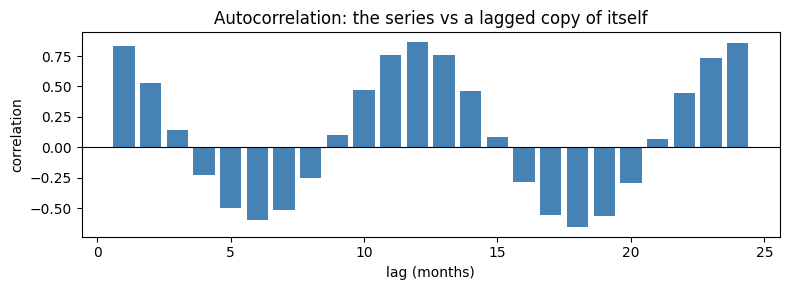

Correlation with itself 12 months ago: +0.869
Correlation with itself 6 months ago:  -0.598


In [10]:
lags = range(1, 25)
acf = [temp_m.autocorr(lag) for lag in lags]

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(lags, acf, color="steelblue")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("lag (months)")
ax.set_ylabel("correlation")
ax.set_title("Autocorrelation: the series vs a lagged copy of itself")
plt.tight_layout()
plt.show()

print(f"Correlation with itself 12 months ago: {temp_m.autocorr(12):+.3f}")
print(f"Correlation with itself 6 months ago:  {temp_m.autocorr(6):+.3f}")

<details><summary>Expected Output</summary>

~~~text
Correlation with itself 12 months ago: +0.869
Correlation with itself 6 months ago:  -0.598
~~~
</details>

> **Read it:** strong positive correlation at lag 12 (this August looks
> like last August), strong *negative* at lag 6 (August is the opposite of
> February) -- the signature of a 12-month period, detected with nothing
> but a correlation coefficient. The bar chart's peaks at lags 12 and 24
> say the cycle repeats indefinitely. This is **periodicity** found from
> the data alone, no calendar required.

Your turn -- name the seasons from the climatologies:

In [11]:
# Uncomment and fill the ____ : .idxmax() / .idxmin() on a climatology Series
# return the month NUMBER (1 = January ... 12 = December).
# print("Warmest month:", temp_clim.____())
# print("Coolest month:", temp_clim.idxmin())
# print("Wettest month:", rain_clim.idxmax())
# print("Driest month: ", rain_clim.____())

<details><summary>Expected Output</summary>

~~~text
Warmest month: 8
Coolest month: 1
Wettest month: 11
Driest month:  3
~~~
*(August vs January for temperature; November vs March for rain. The two
cycles do not even peak together -- "the" season depends on the variable.)*
</details>

## Step 5: Making Series Comparable (Worked)

Can temperature and rain share one plot? Their units say no -- and plotting
them anyway shows what that means in practice (one recent decade, for
readability):

Temperature range (C):  24.9 to 30.1
Rain range (mm):        26.4 to 448.4


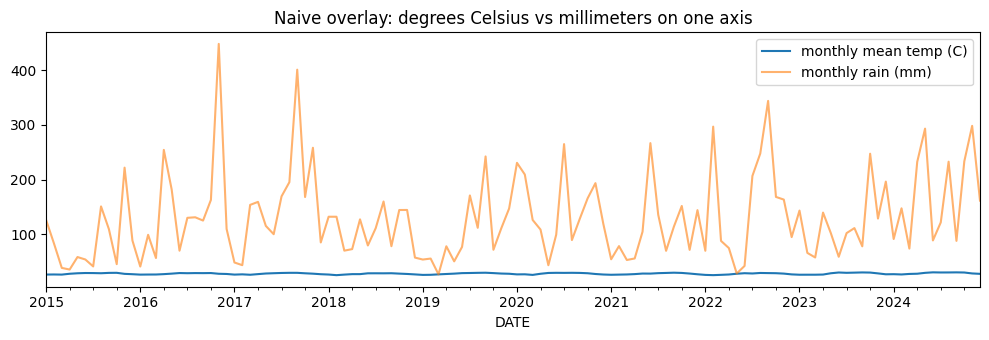

In [12]:
recent_t = temp_m.loc["2015":"2024"]
recent_r = rain_m.loc["2015":"2024"]
print("Temperature range (C): ", round(recent_t.min(), 1), "to", round(recent_t.max(), 1))
print("Rain range (mm):       ", round(recent_r.min(), 1), "to", round(recent_r.max(), 1))

fig, ax = plt.subplots(figsize=(10, 3.5))
recent_t.plot(ax=ax, label="monthly mean temp (C)")
recent_r.plot(ax=ax, alpha=0.6, label="monthly rain (mm)")
ax.legend()
ax.set_title("Naive overlay: degrees Celsius vs millimeters on one axis")
plt.tight_layout()
plt.show()

<details><summary>Expected Output</summary>

~~~text
Temperature range (C):  24.9 to 30.1
Rain range (mm):        26.4 to 448.4
~~~
</details>

> **Read it:** rain spans hundreds of millimeters, temperature five
> degrees -- so the temperature series is squashed into a flat ribbon at
> the bottom of the axis. The plot is not wrong, it is *unreadable*:
> the axis belongs to whichever variable has the bigger numbers.

The fix is **normalization**: put both series on a common, unitless scale.
The **z-score** re-expresses every value as "how many standard deviations
from this series' own mean" -- L07's mean and standard deviation, repurposed
as a ruler:

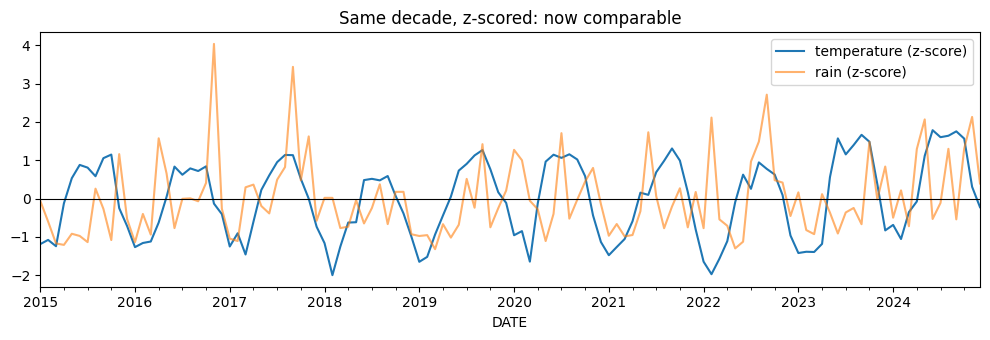

September 2017 rain: 401.2 mm (z = +3.6)


In [13]:
def zscore(s):
    return (s - s.mean()) / s.std()

fig, ax = plt.subplots(figsize=(10, 3.5))
zscore(recent_t).plot(ax=ax, label="temperature (z-score)")
zscore(recent_r).plot(ax=ax, alpha=0.6, label="rain (z-score)")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
ax.set_title("Same decade, z-scored: now comparable")
plt.tight_layout()
plt.show()

print(f"September 2017 rain: {rain_m.loc['2017-09-30']:.1f} mm "
      f"(z = {zscore(rain_m).loc['2017-09-30']:+.1f})")

<details><summary>Expected Output</summary>

~~~text
September 2017 rain: 401.2 mm (z = +3.6)
~~~
</details>

> **Read it:** both series now swing around zero on the same scale, and
> their rhythms can be compared directly. And the z-score doubles as an
> extremeness ruler: computed over all 65 years, Maria's month stands
> 3.6 standard deviations above the average month -- enormous, yet not
> even the record (August 2011, fed by tropical storms Emily and Irene,
> reached z = +4.5).

One more normalization, this time against the *calendar*: subtract from
each month its own climatological normal. What remains is the **anomaly**
-- how unusual the month was *for that month* -- and with the seasonal wave
gone, the trend stands alone. (Climate agencies do exactly this, usually
against a fixed 30-year baseline like 1961-1990; we use the full-window
climatology from Step 4.)

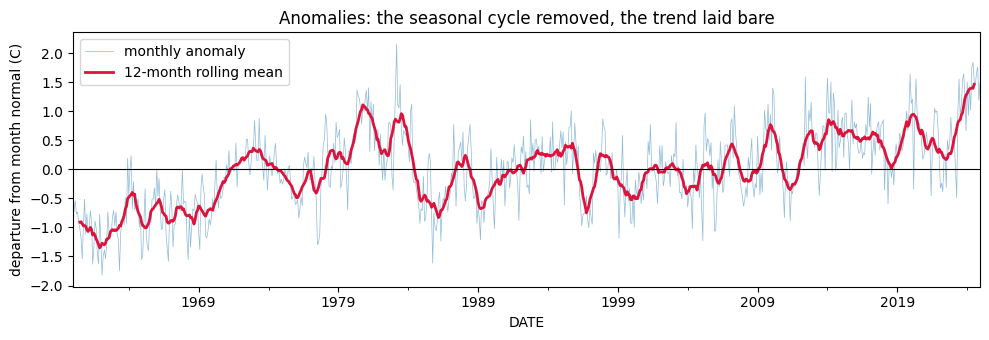

Mean anomaly 1960-1969: -0.86 C
Mean anomaly 2015-2024: +0.63 C


In [14]:
anomaly = temp_m - temp_clim[temp_m.index.month].values   # subtract each month's normal

fig, ax = plt.subplots(figsize=(10, 3.5))
anomaly.plot(ax=ax, linewidth=0.5, alpha=0.5, label="monthly anomaly")
anomaly.rolling(12, center=True).mean().plot(ax=ax, linewidth=2, color="crimson",
                                             label="12-month rolling mean")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("departure from month normal (C)")
ax.legend()
ax.set_title("Anomalies: the seasonal cycle removed, the trend laid bare")
plt.tight_layout()
plt.show()

print(f"Mean anomaly 1960-1969: {anomaly['1960':'1969'].mean():+.2f} C")
print(f"Mean anomaly 2015-2024: {anomaly['2015':'2024'].mean():+.2f} C")

<details><summary>Expected Output</summary>

~~~text
Mean anomaly 1960-1969: -0.86 C
Mean anomaly 2015-2024: +0.63 C
~~~
</details>

> **Read it:** every month is now measured against its own normal, so
> January and August compete fairly. The 1960s sat almost a degree below
> today's normal; the last decade sits above it, and the red rolling mean
> has spent essentially no time below zero since the 1990s. This is the
> cleanest trend view in the lab -- seasonality removed by normalization,
> noise removed by smoothing, trend left standing.

## Your Turn (Exercises)

### Exercise 1 -- The smoothing dial

Smooth the **daily TMAX** series with centered rolling means of 7, 30, and
365 days. Plot the raw series and the three smoothed ones for 2015-2024 on
a single axes, and print the maximum of the raw series and of each
smoothed series (over the full 65 years). One sentence: what does each
widening window reveal, and what does it destroy?

> **Hint:** `weather["TMAX"].rolling(7, center=True).mean()` is the 7-day
> version; `.loc["2015":"2024"]` slices for the plot; `.max()` needs no
> slicing.

In [15]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
raw daily    max: 36.7 C
7-day mean   max: 35.6 C
30-day mean  max: 33.6 C
365-day mean max: 31.7 C
~~~
*(Each widening window shaves the record: the all-time heat record of
36.7 C survives the 7-day average as 35.6, fades to 33.6 at a month, and
has vanished entirely into the annual average. Smoothing removes noise --
and noise removal removes events. The 365-day curve is pure trend; the
heat wave that set the record is gone.)*
</details>

### Exercise 2 -- Hurricane hunting

Print the five wettest single days of the record with `.nlargest()`. Three
of them are famous hurricanes -- which? One sentence: is an extreme day
always a named storm?

> **Hint:** `weather["PRCP"].nlargest(5)`; then put the dates next to the
> hurricane history of Puerto Rico (the concept note names the three).

In [16]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
DATE
2013-07-18    234.4
1989-09-18    224.5
1996-09-10    208.3
2017-09-20    180.6
1988-04-15    180.3
Name: PRCP, dtype: float64
~~~
*(Hugo (1989-09-18), Hortense (1996-09-10), and Maria (2017-09-20) -- but
the wettest day of all, July 18, 2013, was a no-name tropical downpour,
and 1988-04-15 a spring flood. The honesty cut: Maria, the worst disaster,
is only the #4 rain day at this gauge -- "worst" and "wettest at one
station" are different questions.)*
</details>

### Exercise 3 -- Written: pick the one graphic

A newsroom can print ONE graphic for the story "San Juan is getting
hotter". The candidates: Step 1's daily ribbon, Step 3's monthly series
with its 12-month rolling mean, or Step 5's anomaly plot. Argue for one in
3-4 sentences, naming one strength of your choice and one honest weakness
-- and use a number from this lab as evidence.

> **Hint:** which figure makes the +1.5 C visible fastest? Which one would
> a skeptical reader trust most, and which could they accuse of hiding
> the messy raw data?

## Summary

| Move | Key commands | What you learned |
|------|-------------|------------------|
| Make it a time series | `parse_dates=`, `set_index`, `.loc["2017-09"]` | Timestamps as the index unlock date slicing |
| Fill gaps time-aware | `.interpolate(method="time")` | Neighbors in time, not the column median (5 gap days; Maria's outage) |
| Change scale | `.resample("ME").mean()` / `.sum()` | Each pattern is visible at one scale; mean for levels, sum for amounts |
| Extract trend | `.rolling(12, center=True).mean()` | A 12-month window cancels the seasonal wave: +1.5 C since the 1960s |
| Extract seasons | `.groupby(index.month).mean()` | The climatology: 3.2 C amplitude; rain peaks in November |
| Detect the period | `.autocorr(lag)` | L08's correlation, lagged: +0.87 at 12 months, -0.60 at 6 |
| Compare series | z-score; anomaly vs climatology | Normalization makes units comparable and de-seasonalizes |

Next lesson (L14): patterns across *many variables* at once -- and how to
squeeze a dozen columns into a picture you can actually read.